## Лабораторная работа №2 (Линейная и Логистическая регрессия + Ridge, Lasso, ElasticNet)
Группа: М8О-409Б-22
Студент: Воропаев Иван Константинович

Устанавливаем все необходимые Python-пакеты для проведения исследования:
- **numpy, pandas** - обработка данных
- **matplotlib, seaborn** - визуализация
- **scikit-learn** - базовые алгоритмы машинного обучения
- **optuna** - автоматическая оптимизация гиперпараметров
- **boruta** - алгоритм отбора признаков

In [180]:
import sys
import subprocess

def install_packages():
    packages = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'optuna', 'boruta']
    print('Установка библиотек...')
    for package in packages:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
            print(f'✓ {package}')
        except:
            print(f'✗ {package}')
    print('Готово!')

install_packages()

Установка библиотек...


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✓ numpy


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✓ pandas


...

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✓ scikit-learn


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✓ optuna
✓ boruta
Готово!


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## Импорт библиотек

Импортируем все необходимые модули для исследования. Используем:
- **Препроцессинг**: OneHotEncoder, PolynomialFeatures, различные Scaler'ы
- **Модели**: KNN для классификации и регрессии, Random Forest
- **Отбор признаков**: RFECV, Boruta
- **Валидация**: cross_val_score, различные метрики качества

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import (OneHotEncoder, PolynomialFeatures,
                                   StandardScaler, MinMaxScaler, RobustScaler,
                                   PowerTransformer, QuantileTransformer)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.feature_selection import RFECV
from sklearn.metrics import make_scorer, accuracy_score, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Лабораторная работа №2: Линейная и Логистическая регрессия + Ridge, Lasso, ElasticNet')

Лабораторная работа №2: Линейная и Логистическая регрессия + Ridge, Lasso, ElasticNet


## Huber Loss Scorer

Создаём scorer на основе **Huber Loss** для оптимизации задачи регрессии.

**Формула:** L(y, ŷ) = 0.5×(y-ŷ)² при |ε|≤δ, иначе δ×(|ε|-0.5δ)

**Параметр δ = 1.35** (стандартное значение)

**1c. Выбор метрик:**
- **Классификация**: **Accuracy** (основная), Precision, Recall
- **Регрессия**: **Huber Loss** (основная), RMSE, R²

**Обоснование:**
- **Accuracy**: устойчивая метрика при умеренном дисбалансе классов (38%/62%)
- **Precision/Recall**: позволяют отслеживать баланс ошибок разных типов
- **Huber Loss**: робастна к выбросам в Fare (£0-£512)

In [182]:
from sklearn.metrics import mean_absolute_error

def huber_loss(y_true, y_pred, delta=1.35):
    error = np.abs(y_true - y_pred)
    quadratic_part = np.minimum(error, delta)
    linear_part = error - quadratic_part
    return np.mean(0.5 * quadratic_part**2 + delta * linear_part)

huber_scorer = make_scorer(huber_loss, greater_is_better=False, delta=1.35)
print('Huber Loss scorer настроен с δ=1.35')

Huber Loss scorer настроен с δ=1.35


## 1. Загрузка и препроцессинг данных

### Пункт 1: Выбор начальных условий

**1a-1b. Выбор датасета и задач:**
- **Датасет**: Titanic
- **Задача классификации**: предсказание выживания (Survived: 0/1)
- **Задача регрессии**: предсказание стоимости билета (Fare)

### Загрузка тренировочных данных

Загружаем датасет Titanic и выполняем первичный анализ:
- Проверяем размерность данных
- Изучаем список признаков
- Анализируем наличие пропущенных значений

In [183]:
df = pd.read_csv('../train.csv')
print(f'Колонки: {list(df.columns)}')
print(f'\nПропуски:\n{df.isnull().sum()}')

Колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Пропуски:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Предобработка данных: удаление пропусков

**Стратегия обработки пропусков:**
- Удаляем нерелевантные признаки: PassengerId, Name, Ticket, Cabin
- Удаляем строки с пропущенными значениями (более чистый подход для обучения)
- Анализируем потерю данных

Удаление строк предпочтительнее заполнения пропусков, когда:
- Процент пропусков невелик 
- Важна чистота обучающей выборки (наш случай)
- Нет явных паттернов в пропущенных значениях (наш случай)

### Exploratory Data Analysis (EDA)

Визуализируем ключевые характеристики данных:
1. **Распределение целевых переменных** (Survived, Fare)
2. **Корреляционная матрица** числовых признаков
3. **Выживаемость по категориям** (пол, класс)
4. **Распределение Fare по классам**

Цель EDA - выявить закономерности, которые помогут в feature engineering.

In [184]:
df_processed = df.copy()
df_processed = df_processed.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print(df_processed.isnull().sum())
print(f'\nВсего строк: {len(df_processed)}')

df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)
if 'Embarked' in df_processed.columns:
    df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)

df_processed = df_processed.dropna()

print(f'\nПосле очистки: {len(df)} → {len(df_processed)} ({(len(df) - len(df_processed))/len(df)*100:.2f}% удалено)')
print(f'Пропусков: {df_processed.isnull().sum().sum()}')
print(f'Размер: {df_processed.shape}')

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Всего строк: 891

После очистки: 891 → 891 (0.00% удалено)
Пропусков: 0
Размер: (891, 8)


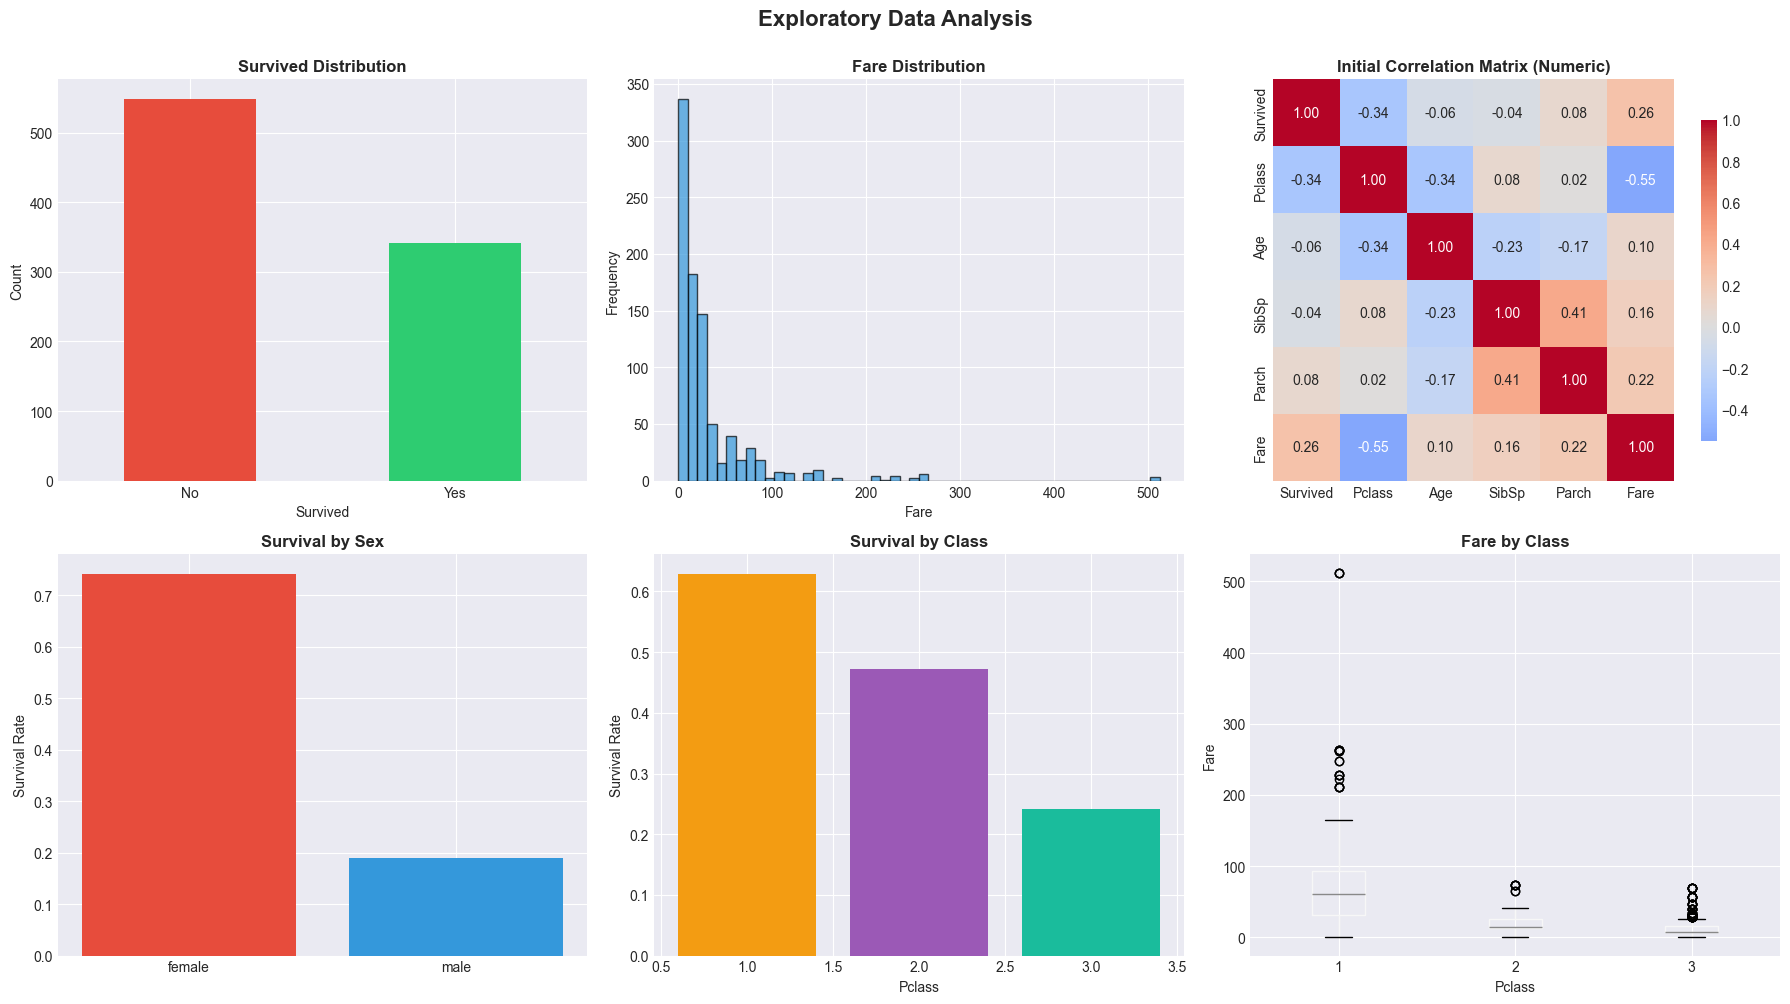

In [185]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df_processed['Survived'].value_counts().plot(kind='bar', ax=axes[0,0],
                                              color=['#e74c3c', '#2ecc71'])
axes[0,0].set_title('Survived Distribution', fontweight='bold', fontsize=12)
axes[0,0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[0,0].set_ylabel('Count')

axes[0,1].hist(df_processed['Fare'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Fare Distribution', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Fare')
axes[0,1].set_ylabel('Frequency')

temp_df = df_processed.select_dtypes(include=[np.number]).copy()
sns.heatmap(temp_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0,2], cbar_kws={"shrink": 0.8})
axes[0,2].set_title('Initial Correlation Matrix (Numeric)', fontweight='bold', fontsize=12)

survival_by_sex = df_processed.groupby('Sex')['Survived'].mean()
axes[1,0].bar(range(len(survival_by_sex)), survival_by_sex.values,
              color=['#e74c3c', '#3498db'], tick_label=survival_by_sex.index)
axes[1,0].set_title('Survival by Sex', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Survival Rate')

survival_by_class = df_processed.groupby('Pclass')['Survived'].mean()
axes[1,1].bar([1, 2, 3], survival_by_class.values,
              color=['#f39c12', '#9b59b6', '#1abc9c'])
axes[1,1].set_title('Survival by Class', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Pclass')
axes[1,1].set_ylabel('Survival Rate')

df_processed.boxplot(column='Fare', by='Pclass', ax=axes[1,2])
axes[1,2].set_title('Fare by Class', fontweight='bold', fontsize=12)
axes[1,2].set_xlabel('Pclass')
axes[1,2].set_ylabel('Fare')
plt.suptitle('')

plt.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Feature Engineering и Полиномиальные признаки

### Этап 1: Кодирование категориальных признаков (One-Hot Encoding)

**Проблема**: Категориальные признаки (Sex, Embarked) нельзя напрямую использовать в моделях.

**Решение**: OneHot Encoding преобразует категории в бинарные признаки:
- Sex → Sex_male (0/1)
- Embarked → Embarked_Q, Embarked_S (0/1)

**Преимущества** перед Label Encoding:
- Нет искусственного порядка между категориями
- Модели корректно работают с расстояниями и весами
- Параметр `drop='first'` исключает мультиколлинеарность

### Подготовка признаков и целевых переменных

Разделяем данные на признаки (X) и целевые переменные (y):
- **Классификация**: X = все признаки кроме Survived/Fare, y = Survived
- **Регрессия**: X = все признаки кроме Survived/Fare, y = Fare

Одинаковый набор базовых признаков для обеих задач обеспечивает консистентность эксперимента.

In [186]:
# Для классификации (Survived)
X_classification = df_processed.drop('Survived', axis=1)
y_classification = df_processed['Survived'].values
X_classification = pd.get_dummies(X_classification, drop_first=True)

# Для регрессии (Fare)
X_regression = df_processed.drop('Fare', axis=1)
y_regression = df_processed['Fare'].values
X_regression = pd.get_dummies(X_regression, drop_first=True)

# Полиномиальные признаки
poly_degree = 2

poly_classification = PolynomialFeatures(degree=poly_degree, include_bias=False)
X_classification_poly = poly_classification.fit_transform(X_classification)
poly_feature_names_classification = poly_classification.get_feature_names_out(X_classification.columns)

poly_regression = PolynomialFeatures(degree=poly_degree, include_bias=False)
X_regression_poly = poly_regression.fit_transform(X_regression)
poly_feature_names_regression = poly_regression.get_feature_names_out(X_regression.columns)

print(f'Классификация: {X_classification_poly.shape[0]} строк, {X_classification_poly.shape[1]} признаков')
print(f'Регрессия: {X_regression_poly.shape[0]} строк, {X_regression_poly.shape[1]} признаков')

Классификация: 891 строк, 44 признаков
Регрессия: 891 строк, 44 признаков


### Этап 2: Создание полиномиальных признаков

**Гипотеза**: Взаимодействия между признаками (например, Pclass × Sex) могут улучшить качество модели.

**Реализация**: PolynomialFeatures(degree=2) создаёт:
- Исходные признаки (x₁, x₂, ...)
- Попарные произведения (x₁×x₂, x₁×x₃, ...)
- Квадраты признаков (x₁², x₂², ...)

**Результат**: Резкое увеличение размерности (например, 8 → 44 признака).

**Следствие**: Необходим отбор признаков на следующих этапах.

### Анализ корреляций полиномиальных признаков

Визуализируем наиболее коррелирующие полиномиальные признаки **для обеих задач**:
- Классификация: топ-30 по связи с `Survived`
- Регрессия: топ-30 по связи с `Fare`

**Цели анализа**:
1. Выявить наиболее информативные взаимодействия
2. Обнаружить мультиколлинеарность в расширенном признаковом пространстве
3. Сопоставить различия между задачами классификации и регрессии

Это помогает интерпретировать результаты последующего отбора признаков.

## Визуализация корреляций


ТОП-10 признаков (Классификация):
 1. Sex_male^2                               0.5434
 2. Sex_male                                 0.5434
 3. Pclass Sex_male                          0.5425
 4. Age Sex_male                             0.4781
 5. Sex_male Embarked_S                      0.4259
 6. Pclass^2                                 0.3397
 7. Pclass                                   0.3385
 8. Pclass Age                               0.3246
 9. Pclass Embarked_S                        0.2833
10. Fare                                     0.2573

ТОП-10 признаков (Регрессия):
 1. Pclass                                   0.5495
 2. Pclass^2                                 0.5197
 3. Pclass Age                               0.3532
 4. Pclass Sex_male                          0.3222
 5. Pclass Embarked_S                        0.3184
 6. Survived Age                             0.2884
 7. Survived                                 0.2573
 8. Survived^2                               0.257

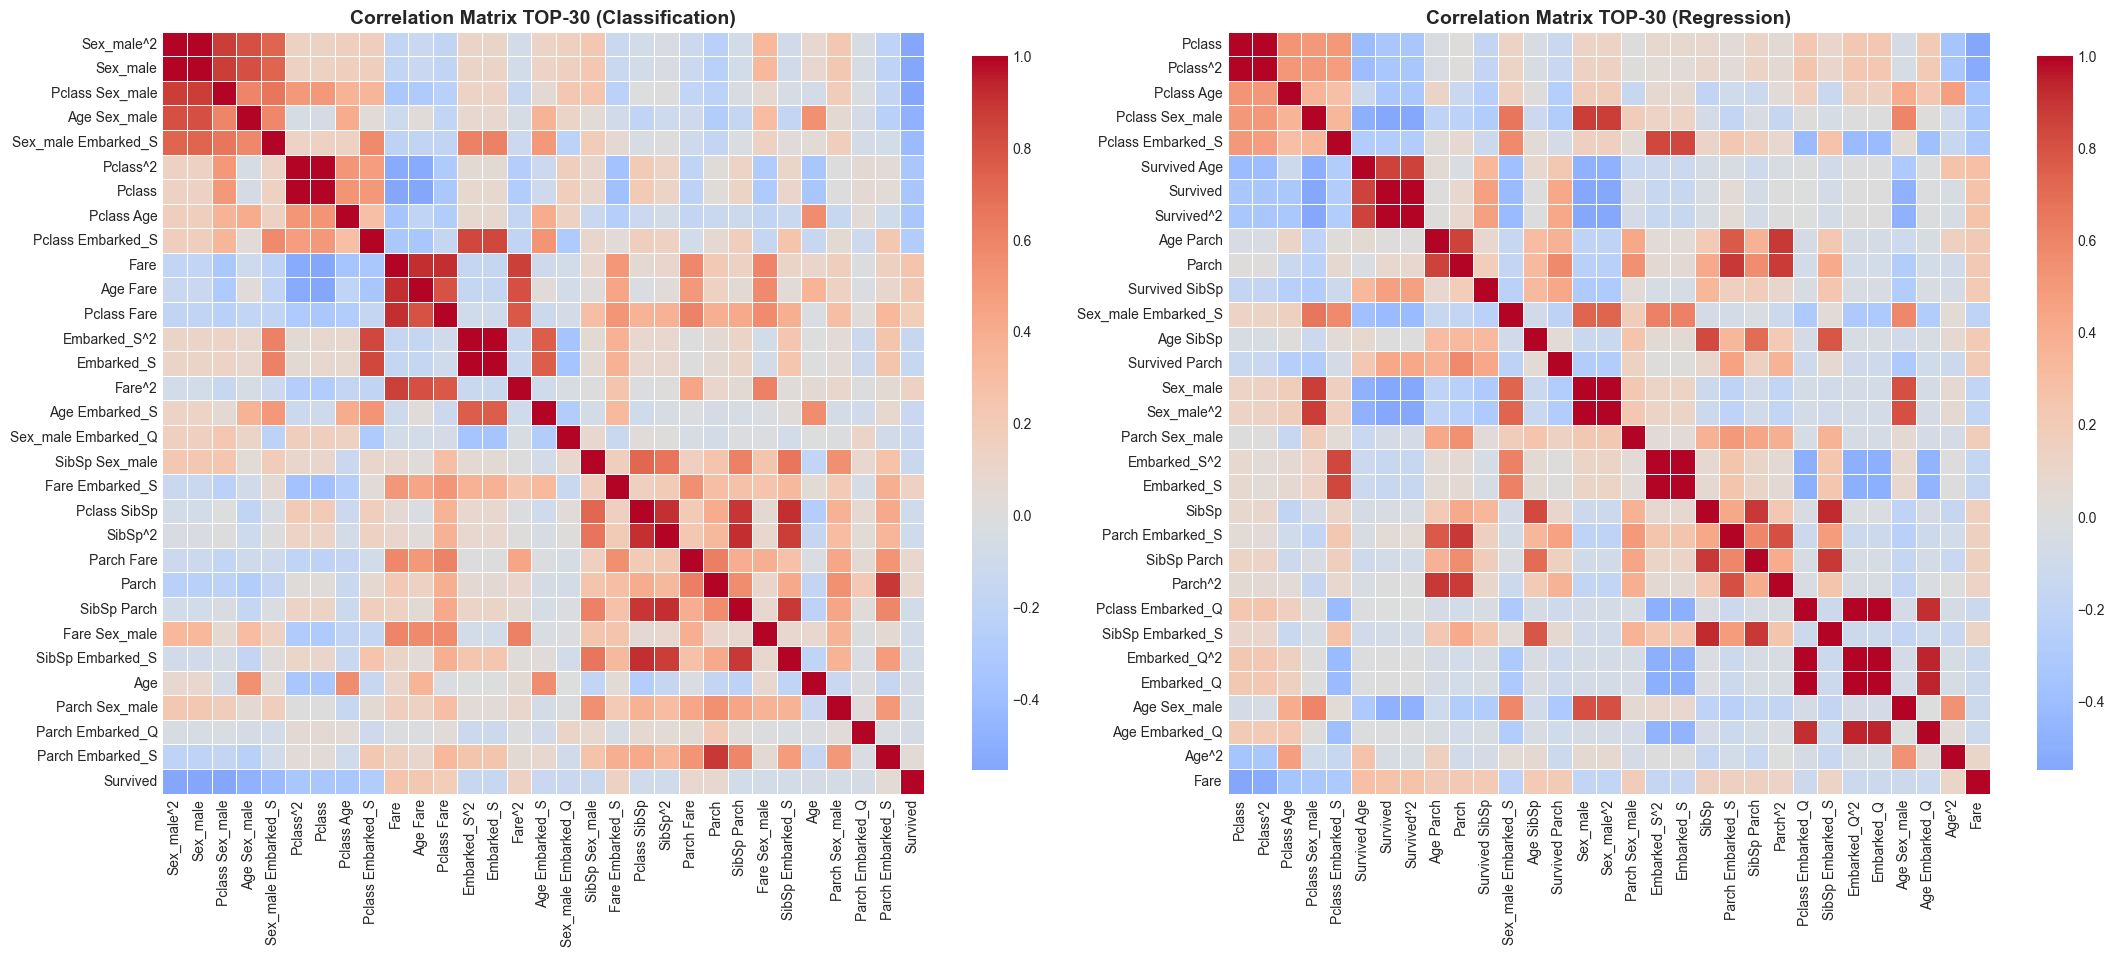

In [187]:
X_poly_clf_df = pd.DataFrame(X_classification_poly, columns=poly_feature_names_classification)
X_poly_clf_df['Survived'] = y_classification

X_poly_reg_df = pd.DataFrame(X_regression_poly, columns=poly_feature_names_regression)
X_poly_reg_df['Fare'] = y_regression

correlations_clf = X_poly_clf_df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)
correlations_reg = X_poly_reg_df.corr()['Fare'].drop('Fare').abs().sort_values(ascending=False)

print('\nТОП-10 признаков (Классификация):')
for i, (feat, corr) in enumerate(correlations_clf.head(10).items(), 1):
    print(f'{i:2d}. {feat:40} {corr:.4f}')

print('\nТОП-10 признаков (Регрессия):')
for i, (feat, corr) in enumerate(correlations_reg.head(10).items(), 1):
    print(f'{i:2d}. {feat:40} {corr:.4f}')

top_n_clf = min(30, len(correlations_clf))
top_features_clf = correlations_clf.head(top_n_clf).index.tolist() + ['Survived']

top_n_reg = min(30, len(correlations_reg))
top_features_reg = correlations_reg.head(top_n_reg).index.tolist() + ['Fare']

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

corr_subset_clf = X_poly_clf_df[top_features_clf].corr()
sns.heatmap(corr_subset_clf, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=axes[0])
axes[0].set_title(f'Correlation Matrix TOP-{top_n_clf} (Classification)',
                  fontsize=14, fontweight='bold')

corr_subset_reg = X_poly_reg_df[top_features_reg].corr()
sns.heatmap(corr_subset_reg, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title(f'Correlation Matrix TOP-{top_n_reg} (Regression)',
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

del X_poly_clf_df, X_poly_reg_df

## Функция для получения Scaler

In [188]:
def get_scaler(scaler_name):
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
        'power': PowerTransformer(method='yeo-johnson', standardize=True),
        'quantile': QuantileTransformer(output_distribution='normal', random_state=42)
    }
    return scalers.get(scaler_name, StandardScaler())

# ================================
# ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
# ================================

### Навигация по дальнейшим шагам
Кратко отмечаем, что ниже идут этапы подбора скейлеров, Boruta и RFECV для каждой модели. Детали привязаны к соответствующим шагам (логистическая, линейная, Ridge, Lasso, ElasticNet).

## 1. Подбор Scaler через Optuna (Logistic Regression)
Подбираем scaler для полиномиальных признаков классификации: 25 trials Optuna, метрика — accuracy, модель — LogisticRegression (5-fold CV). Лучший scaler сохраняем для дальнейших шагов.

In [ ]:
def objective_scaler_logistic(trial):
    scaler_name = trial.suggest_categorical('scaler', ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_classification_poly)
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    cv_scores = cross_val_score(model, X_scaled, y_classification, cv=5, scoring='accuracy', n_jobs=-1)
    
    return cv_scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_scaler_logistic = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_scaler_logistic.optimize(objective_scaler_logistic, n_trials=25, show_progress_bar=True)

best_scaler_logistic = study_scaler_logistic.best_params['scaler']
print(f'\nЛучший scaler для Logistic Regression: {best_scaler_logistic}')
print(f'Accuracy: {study_scaler_logistic.best_value:.4f}')

## 2. Применение Scaler и Boruta (Logistic Regression)
Масштабируем X_classification_poly оптимальным scaler'ом и запускаем Boruta с RandomForestClassifier (n_estimators=100, max_depth=5). Оставляем признаки с support=True и выводим их число.

In [ ]:
scaler_logistic = get_scaler(best_scaler_logistic)
X_logistic_scaled = scaler_logistic.fit_transform(X_classification_poly)

# Optuna-подбор параметров Boruta (как в ЛР1)
def objective_boruta_logistic(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        random_state=42,
        verbose=0
    )

    boruta.fit(X_logistic_scaled, y_classification)
    selected = boruta.support_ | boruta.support_weak_
    if selected.sum() == 0:
        return 0.0

    X_selected = X_logistic_scaled[:, selected]
    model = LogisticRegression(max_iter=1000, random_state=42)
    cv_scores = cross_val_score(model, X_selected, y_classification, cv=3, scoring='accuracy', n_jobs=-1)
    return cv_scores.mean()

study_boruta_logistic = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_boruta_logistic.optimize(objective_boruta_logistic, n_trials=50, show_progress_bar=True)

best_boruta_params_logistic = study_boruta_logistic.best_params
print('Лучшие параметры Boruta (logistic):', best_boruta_params_logistic)

rf_best_logistic = RandomForestClassifier(
    n_estimators=best_boruta_params_logistic['n_estimators'],
    max_depth=best_boruta_params_logistic['rf_max_depth'],
    min_samples_split=best_boruta_params_logistic['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_logistic['rf_min_samples_leaf'],
    max_features=best_boruta_params_logistic['rf_max_features'],
    class_weight=best_boruta_params_logistic['class_weight'],
    n_jobs=-1,
    random_state=42
)

boruta_logistic = BorutaPy(
    estimator=rf_best_logistic,
    n_estimators='auto',
    max_iter=best_boruta_params_logistic['max_iter'],
    perc=best_boruta_params_logistic['perc'],
    alpha=best_boruta_params_logistic['alpha'],
    random_state=42,
    verbose=0
)
boruta_logistic.fit(X_logistic_scaled, y_classification)
selected_features_logistic = boruta_logistic.support_ | boruta_logistic.support_weak_
X_logistic_boruta = X_logistic_scaled[:, selected_features_logistic]

print(f'Boruta выбрал {X_logistic_boruta.shape[1]} признаков из {X_logistic_scaled.shape[1]}')

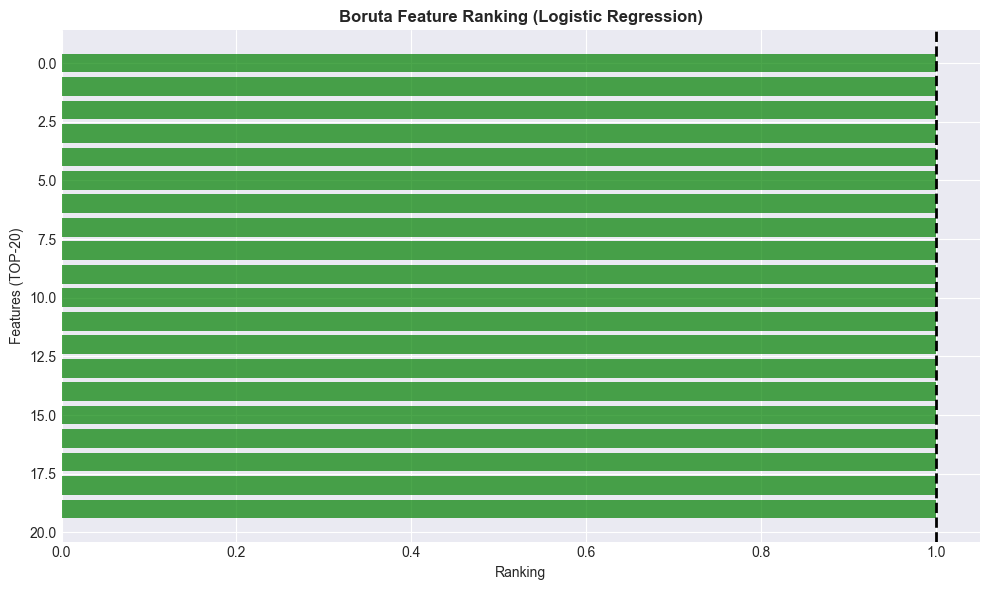

In [191]:
feature_ranks_logistic = pd.DataFrame({
    'Feature': poly_feature_names_classification,
    'Ranking': boruta_logistic.ranking_,
    'Selected': selected_features_logistic
}).sort_values('Ranking')

colors_logistic = ['green' if flag else 'red' for flag in feature_ranks_logistic['Selected']]
top_show = min(20, len(feature_ranks_logistic))

plt.figure(figsize=(10, 6))
plt.barh(range(top_show), feature_ranks_logistic['Ranking'].values[:top_show],
         color=colors_logistic[:top_show], alpha=0.7)
plt.xlabel('Ranking')
plt.ylabel('Features (TOP-20)')
plt.title('Boruta Feature Ranking (Logistic Regression)', fontweight='bold')
plt.axvline(x=1, color='black', linestyle='--', linewidth=2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Optuna + RFECV (Logistic Regression)
Оптимизируем C и penalty (l1/l2) у LogisticRegression через Optuna (150 trials). Для каждого набора параметров RFECV отбирает признаки на выходе Boruta, затем считаем accuracy 5-fold.

In [ ]:
def objective_logistic_rfecv(trial):
    C = trial.suggest_float('C', 0.001, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000, random_state=42)
    
    rfecv = RFECV(estimator=model, step=1, cv=3, scoring='accuracy', n_jobs=-1)
    rfecv.fit(X_logistic_boruta, y_classification)
    
    X_rfecv = X_logistic_boruta[:, rfecv.support_]
    
    cv_scores = cross_val_score(model, X_rfecv, y_classification, cv=5, scoring='accuracy', n_jobs=-1)
    
    return cv_scores.mean()

study_logistic = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_logistic.optimize(objective_logistic_rfecv, n_trials=150, show_progress_bar=True)

print(f'\nЛучшие гиперпараметры Logistic Regression:')
print(study_logistic.best_params)
print(f'Best Accuracy: {study_logistic.best_value:.4f}')

## 4. Финальная модель и визуализация (Logistic Regression)

Фиксируем найденные шаги: обучаем LogisticRegression на признаках RFECV,
строим кривую зависимости accuracy от числа признаков и сохраняем
пакет (scaler + Boruta + RFECV + модель) для воспроизводимости.

In [ ]:
best_params_logistic = study_logistic.best_params
penalty = best_params_logistic['penalty']
solver = 'liblinear' if penalty == 'l1' else 'lbfgs'

final_model_logistic = LogisticRegression(
    C=best_params_logistic['C'],
    penalty=penalty,
    solver=solver,
    max_iter=1000,
    random_state=42
)

rfecv_logistic = RFECV(estimator=final_model_logistic, step=1, cv=3, scoring='accuracy', n_jobs=-1)
rfecv_logistic.fit(X_logistic_boruta, y_classification)

X_logistic_final = X_logistic_boruta[:, rfecv_logistic.support_]

final_model_logistic.fit(X_logistic_final, y_classification)

print(f'\nФинальная модель Logistic Regression обучена на {X_logistic_final.shape[1]} признаках')

# Визуализация RFECV
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv_logistic.cv_results_['mean_test_score']) + 1),
         rfecv_logistic.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('Cross-validation Score (Accuracy)')
plt.title('RFECV - Logistic Regression')
plt.grid(True)
plt.show()

# Сохранение
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler_logistic,
        'boruta': boruta_logistic,
        'rfecv': rfecv_logistic,
        'model': final_model_logistic,
        'best_params': best_params_logistic
    }, f)

print('Модель сохранена в logistic_regression_model.pkl')

# ================================
# LINEAR REGRESSION
# ================================

## 1. Подбор Scaler через Optuna (Linear Regression)

25 trials Optuna: подбираем scaler для регрессии (LinearRegression),
метрика — Huber Loss, 5-fold CV. Сохраняем лучший scaler.

In [ ]:
def objective_scaler_linear(trial):
    scaler_name = trial.suggest_categorical('scaler', ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_regression_poly)
    
    model = LinearRegression()
    cv_scores = cross_val_score(model, X_scaled, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_scaler_linear = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_scaler_linear.optimize(objective_scaler_linear, n_trials=25, show_progress_bar=True)

best_scaler_linear = study_scaler_linear.best_params['scaler']
print(f'\nЛучший scaler для Linear Regression: {best_scaler_linear}')
print(f'Huber Loss: {study_scaler_linear.best_value:.4f}')

## 2. Применение Scaler и Boruta (Linear Regression)

Масштабируем X_regression_poly лучшим scaler'ом и запускаем Boruta
(RandomForestRegressor) для отбора значимых признаков перед RFECV.

In [ ]:
scaler_linear = get_scaler(best_scaler_linear)
X_linear_scaled = scaler_linear.fit_transform(X_regression_poly)

# Optuna-подбор Boruta для Linear Regression
def objective_boruta_linear(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        random_state=42,
        verbose=0
    )

    boruta.fit(X_linear_scaled, y_regression)
    selected = boruta.support_ | boruta.support_weak_
    if selected.sum() == 0:
        return 1e9

    X_selected = X_linear_scaled[:, selected]
    model = LinearRegression()
    scores = -cross_val_score(model, X_selected, y_regression, cv=3, scoring=huber_scorer, n_jobs=-1)
    return scores.mean()

study_boruta_linear = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_boruta_linear.optimize(objective_boruta_linear, n_trials=50, show_progress_bar=True)

best_boruta_params_linear = study_boruta_linear.best_params
print('Лучшие параметры Boruta (linear):', best_boruta_params_linear)

rf_best_linear = RandomForestRegressor(
    n_estimators=best_boruta_params_linear['n_estimators'],
    max_depth=best_boruta_params_linear['rf_max_depth'],
    min_samples_split=best_boruta_params_linear['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_linear['rf_min_samples_leaf'],
    max_features=best_boruta_params_linear['rf_max_features'],
    n_jobs=-1,
    random_state=42
)

boruta_linear = BorutaPy(
    estimator=rf_best_linear,
    n_estimators='auto',
    max_iter=best_boruta_params_linear['max_iter'],
    perc=best_boruta_params_linear['perc'],
    alpha=best_boruta_params_linear['alpha'],
    random_state=42,
    verbose=0
)
boruta_linear.fit(X_linear_scaled, y_regression)
selected_features_linear = boruta_linear.support_ | boruta_linear.support_weak_
X_linear_boruta = X_linear_scaled[:, selected_features_linear]

print(f'Boruta выбрал {X_linear_boruta.shape[1]} признаков из {X_linear_scaled.shape[1]}')

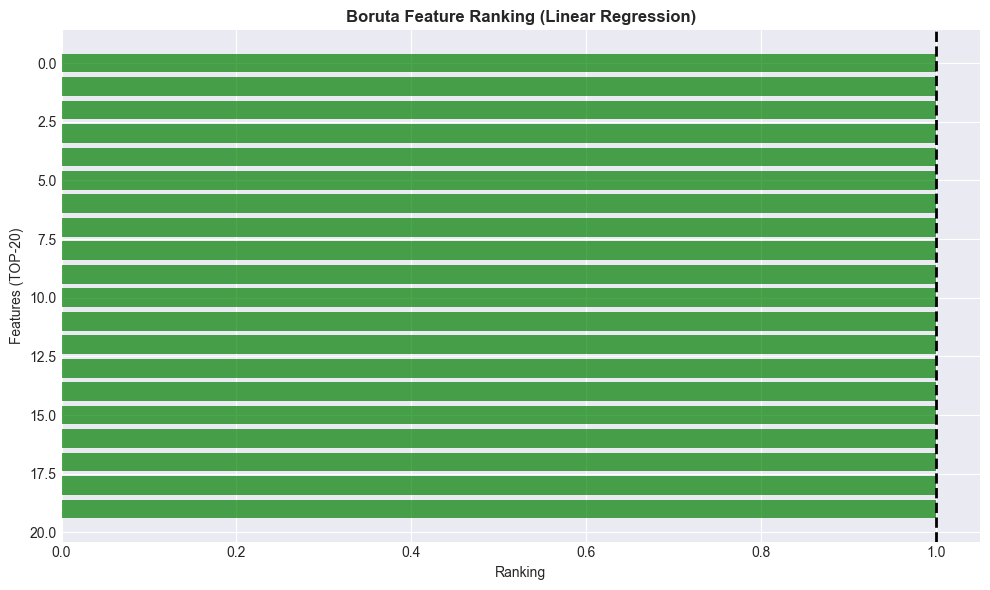

In [197]:
feature_ranks_linear = pd.DataFrame({
    'Feature': poly_feature_names_regression,
    'Ranking': boruta_linear.ranking_,
    'Selected': selected_features_linear
}).sort_values('Ranking')

colors_linear = ['green' if flag else 'red' for flag in feature_ranks_linear['Selected']]
top_show = min(20, len(feature_ranks_linear))

plt.figure(figsize=(10, 6))
plt.barh(range(top_show), feature_ranks_linear['Ranking'].values[:top_show],
         color=colors_linear[:top_show], alpha=0.7)
plt.xlabel('Ranking')
plt.ylabel('Features (TOP-20)')
plt.title('Boruta Feature Ranking (Linear Regression)', fontweight='bold')
plt.axvline(x=1, color='black', linestyle='--', linewidth=2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Топ-10 отобранных признаков (логистическая регрессия):
   1. Sex_male^2                               0.5434
   2. Sex_male                                 0.5434
   3. Pclass Sex_male                          0.5425
   4. Age Sex_male                             0.4781
   5. Sex_male Embarked_S                      0.4259
   6. Pclass^2                                 0.3397
   7. Pclass                                   0.3385
   8. Pclass Age                               0.3246
   9. Pclass Embarked_S                        0.2833
  10. Fare                                     0.2573

Топ-10 отобранных признаков (линейная регрессия):
   1. Pclass                                   0.5495
   2. Pclass^2                                 0.5197
   3. Pclass Age                               0.3532
   4. Pclass Sex_male                          0.3222
   5. Pclass Embarked_S                        0.3184
   6. Survived Age                             0.2884
   7. Survived                

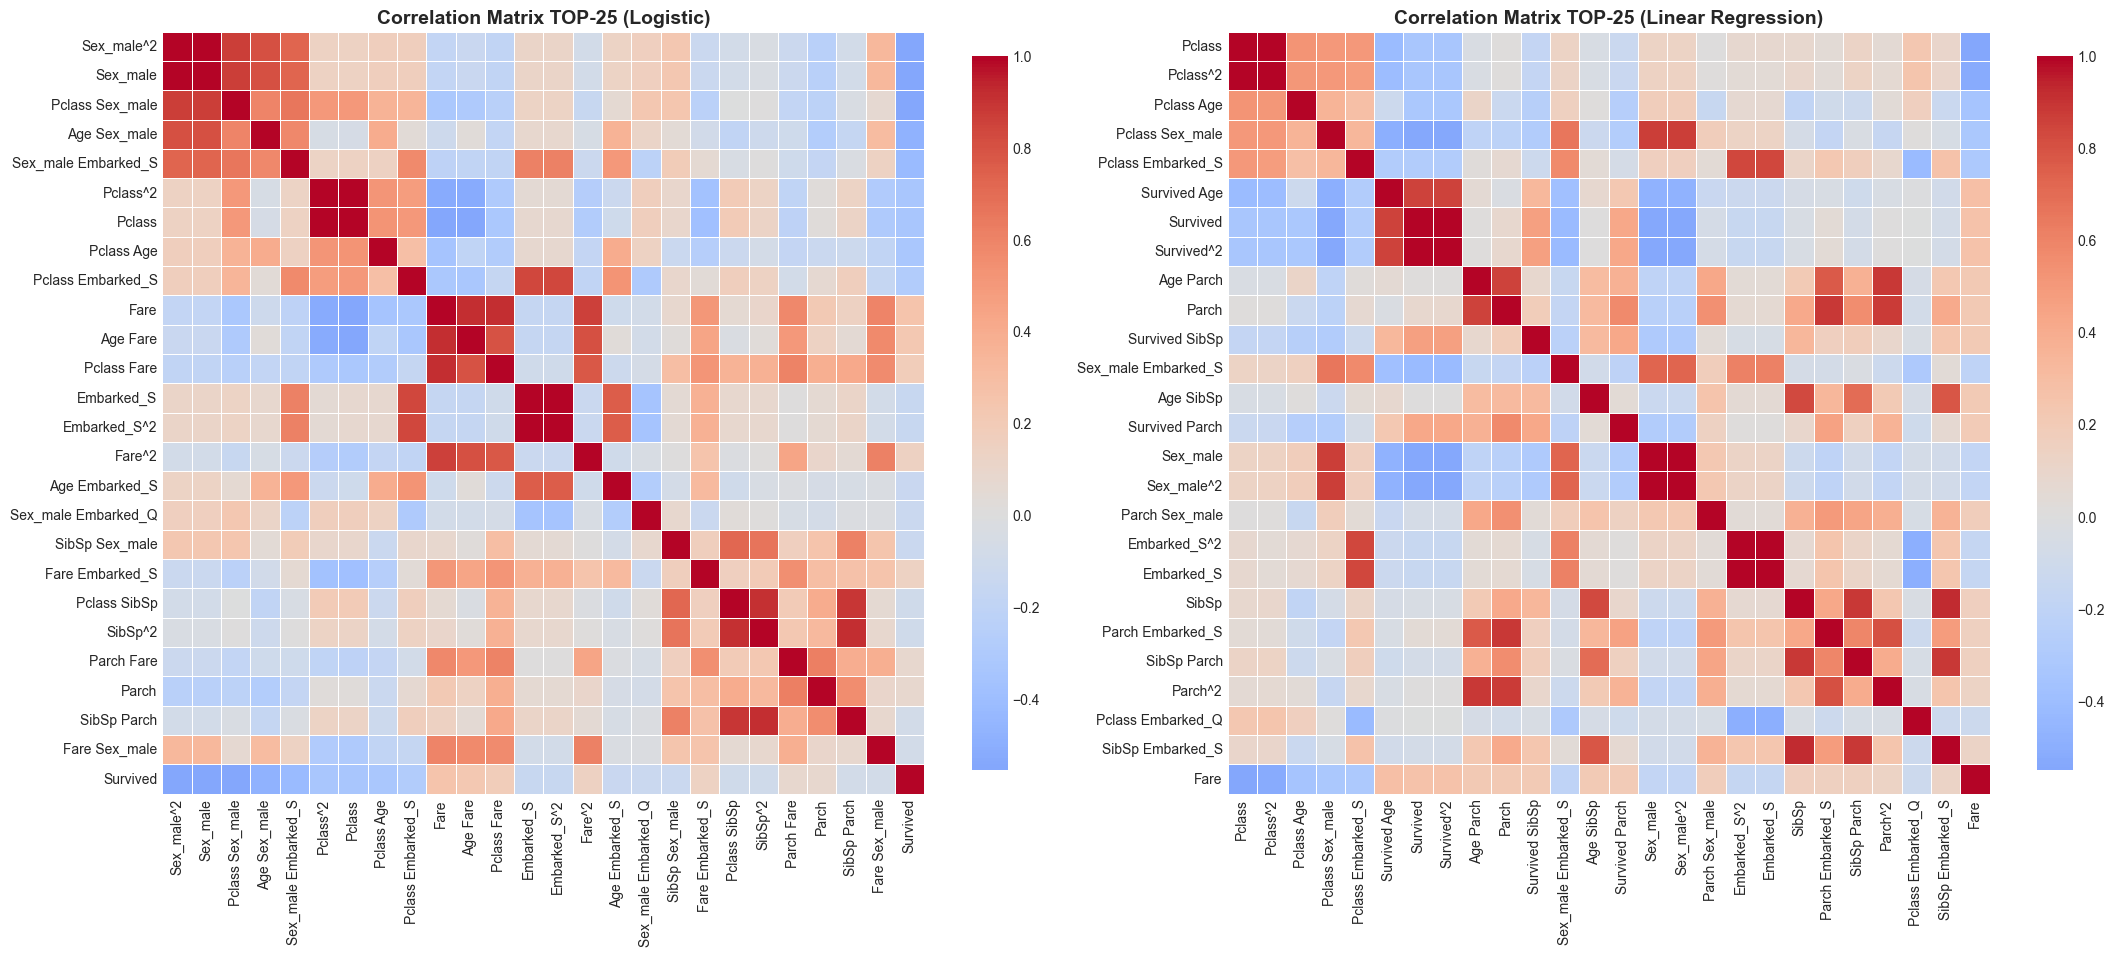

In [198]:
log_features_selected = poly_feature_names_classification[selected_features_logistic]
lin_features_selected = poly_feature_names_regression[selected_features_linear]

X_logistic_boruta_df = pd.DataFrame(X_logistic_boruta, columns=log_features_selected)
X_logistic_boruta_df['Survived'] = y_classification

X_linear_boruta_df = pd.DataFrame(X_linear_boruta, columns=lin_features_selected)
X_linear_boruta_df['Fare'] = y_regression

correlations_log = X_logistic_boruta_df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)
correlations_lin = X_linear_boruta_df.corr()['Fare'].drop('Fare').abs().sort_values(ascending=False)

print("Топ-10 отобранных признаков (логистическая регрессия):")
for i, (feat, corr) in enumerate(correlations_log.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

print("\nТоп-10 отобранных признаков (линейная регрессия):")
for i, (feat, corr) in enumerate(correlations_lin.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

top_n_log = min(25, len(log_features_selected))
top_features_log = correlations_log.head(top_n_log).index.tolist() + ['Survived']

top_n_lin = min(25, len(lin_features_selected))
top_features_lin = correlations_lin.head(top_n_lin).index.tolist() + ['Fare']

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

corr_subset_log = X_logistic_boruta_df[top_features_log].corr()
sns.heatmap(corr_subset_log, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=axes[0])
axes[0].set_title(f'Correlation Matrix TOP-{top_n_log} (Logistic)', fontsize=14, fontweight='bold')

corr_subset_lin = X_linear_boruta_df[top_features_lin].corr()
sns.heatmap(corr_subset_lin, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title(f'Correlation Matrix TOP-{top_n_lin} (Linear Regression)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

del X_logistic_boruta_df, X_linear_boruta_df

## 3. Optuna + RFECV (Linear Regression)

Optuna минимизирует Huber Loss: RFECV (Ridge-оценщик) отбирает признаки
после Boruta, затем LinearRegression оценивается на выбранном подмножестве
через 5-fold CV.

In [ ]:
def objective_linear_rfecv(trial):
    model = LinearRegression()
    
    rfecv = RFECV(estimator=Ridge(alpha=1.0), step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
    rfecv.fit(X_linear_boruta, y_regression)
    
    X_rfecv = X_linear_boruta[:, rfecv.support_]
    
    cv_scores = cross_val_score(model, X_rfecv, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_linear = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_linear.optimize(objective_linear_rfecv, n_trials=30, show_progress_bar=True)

print(f'\nBest Huber Loss (Linear Regression): {study_linear.best_value:.4f}')

## 4. Финальная модель и визуализация (Linear Regression)

Обучаем LinearRegression на финальном наборе RFECV, строим кривую
Huber Loss vs число признаков и сохраняем связку scaler + Boruta + RFECV + модель.

In [ ]:
final_model_linear = LinearRegression()

rfecv_linear = RFECV(estimator=Ridge(alpha=1.0), step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
rfecv_linear.fit(X_linear_boruta, y_regression)

X_linear_final = X_linear_boruta[:, rfecv_linear.support_]

final_model_linear.fit(X_linear_final, y_regression)

print(f'\nФинальная модель Linear Regression обучена на {X_linear_final.shape[1]} признаках')

# Визуализация RFECV
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv_linear.cv_results_['mean_test_score']) + 1),
         -rfecv_linear.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('Huber Loss')
plt.title('RFECV - Linear Regression')
plt.grid(True)
plt.show()

# Сохранение
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler_linear,
        'boruta': boruta_linear,
        'rfecv': rfecv_linear,
        'model': final_model_linear
    }, f)

print('Модель сохранена в linear_regression_model.pkl')

# ================================
# RIDGE REGRESSION
# ================================

## 1. Подбор Scaler через Optuna (Ridge)

25 trials Optuna: подбираем scaler для X_regression_poly, модель Ridge,
метрика — Huber Loss, 5-fold CV. Сохраняем имя лучшего scaler.

In [ ]:
def objective_scaler_ridge(trial):
    scaler_name = trial.suggest_categorical('scaler', ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_regression_poly)
    
    model = Ridge(alpha=1.0, random_state=42)
    cv_scores = cross_val_score(model, X_scaled, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_scaler_ridge = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_scaler_ridge.optimize(objective_scaler_ridge, n_trials=25, show_progress_bar=True)

best_scaler_ridge = study_scaler_ridge.best_params['scaler']
print(f'\nЛучший scaler для Ridge: {best_scaler_ridge}')
print(f'Huber Loss: {study_scaler_ridge.best_value:.4f}')

## 2. Применение Scaler и Boruta (Ridge)

Масштабируем X_regression_poly лучшим scaler'ом и запускаем Boruta
(RandomForestRegressor) для отсева шумовых признаков. Оставляем support-маску
и выбранные признаки для дальнейшего RFECV.

In [ ]:
scaler_ridge = get_scaler(best_scaler_ridge)
X_ridge_scaled = scaler_ridge.fit_transform(X_regression_poly)

# Optuna-подбор Boruta для Ridge
def objective_boruta_ridge(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        random_state=42,
        verbose=0
    )

    boruta.fit(X_ridge_scaled, y_regression)
    selected = boruta.support_ | boruta.support_weak_
    if selected.sum() == 0:
        return 1e9

    X_selected = X_ridge_scaled[:, selected]
    model = Ridge(alpha=1.0, random_state=42)
    scores = -cross_val_score(model, X_selected, y_regression, cv=3, scoring=huber_scorer, n_jobs=-1)
    return scores.mean()

study_boruta_ridge = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_boruta_ridge.optimize(objective_boruta_ridge, n_trials=50, show_progress_bar=True)

best_boruta_params_ridge = study_boruta_ridge.best_params
print('Лучшие параметры Boruta (ridge):', best_boruta_params_ridge)

rf_best_ridge = RandomForestRegressor(
    n_estimators=best_boruta_params_ridge['n_estimators'],
    max_depth=best_boruta_params_ridge['rf_max_depth'],
    min_samples_split=best_boruta_params_ridge['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_ridge['rf_min_samples_leaf'],
    max_features=best_boruta_params_ridge['rf_max_features'],
    n_jobs=-1,
    random_state=42
)

boruta_ridge = BorutaPy(
    estimator=rf_best_ridge,
    n_estimators='auto',
    max_iter=best_boruta_params_ridge['max_iter'],
    perc=best_boruta_params_ridge['perc'],
    alpha=best_boruta_params_ridge['alpha'],
    random_state=42,
    verbose=0
)
boruta_ridge.fit(X_ridge_scaled, y_regression)
selected_features_ridge = boruta_ridge.support_ | boruta_ridge.support_weak_
X_ridge_boruta = X_ridge_scaled[:, selected_features_ridge]

print(f'Boruta выбрал {X_ridge_boruta.shape[1]} признаков из {X_ridge_scaled.shape[1]}')

## 3. Optuna + RFECV (Ridge)

Оптимизируем alpha в Ridge через Optuna; RFECV отбирает признаки после Boruta
по Huber Loss. Оцениваем результат на 5-fold CV.

In [ ]:
def objective_ridge_rfecv(trial):
    alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
    
    model = Ridge(alpha=alpha, random_state=42)
    
    rfecv = RFECV(estimator=model, step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
    rfecv.fit(X_ridge_boruta, y_regression)
    
    X_rfecv = X_ridge_boruta[:, rfecv.support_]
    
    cv_scores = cross_val_score(model, X_rfecv, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_ridge = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_ridge.optimize(objective_ridge_rfecv, n_trials=50, show_progress_bar=True)

print(f'\nЛучшие гиперпараметры Ridge:')
print(study_ridge.best_params)
print(f'Best Huber Loss: {study_ridge.best_value:.4f}')

## 4. Финальная модель и визуализация (Ridge)

Финально обучаем Ridge на признаках RFECV, выводим количества признаков
до/после отбора и строим кривую RFECV (Huber Loss). Сохраняем весь стек
преобразований.

In [ ]:
best_params_ridge = study_ridge.best_params

final_model_ridge = Ridge(alpha=best_params_ridge['alpha'], random_state=42)

rfecv_ridge = RFECV(estimator=final_model_ridge, step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
rfecv_ridge.fit(X_ridge_boruta, y_regression)

X_ridge_final = X_ridge_boruta[:, rfecv_ridge.support_]

final_model_ridge.fit(X_ridge_final, y_regression)

print(f'\nФинальная модель Ridge обучена на {X_ridge_final.shape[1]} признаках')

# Визуализация RFECV
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv_ridge.cv_results_['mean_test_score']) + 1),
         -rfecv_ridge.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('Huber Loss')
plt.title('RFECV - Ridge Regression')
plt.grid(True)
plt.show()

# Сохранение
with open('ridge_model.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler_ridge,
        'boruta': boruta_ridge,
        'rfecv': rfecv_ridge,
        'model': final_model_ridge,
        'best_params': best_params_ridge
    }, f)

print('Модель сохранена в ridge_model.pkl')

# ================================
# LASSO REGRESSION
# ================================

## 1. Подбор Scaler через Optuna (Lasso)

25 trials Optuna: выбираем scaler для регрессии под Huber Loss, модель Lasso,
5-fold CV. Фиксируем лучший scaler.

In [ ]:
def objective_scaler_lasso(trial):
    scaler_name = trial.suggest_categorical('scaler', ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_regression_poly)
    
    model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
    cv_scores = cross_val_score(model, X_scaled, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_scaler_lasso = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_scaler_lasso.optimize(objective_scaler_lasso, n_trials=25, show_progress_bar=True)

best_scaler_lasso = study_scaler_lasso.best_params['scaler']
print(f'\nЛучший scaler для Lasso: {best_scaler_lasso}')
print(f'Huber Loss: {study_scaler_lasso.best_value:.4f}')

## 2. Применение Scaler и Boruta (Lasso)

Применяем лучший scaler к X_regression_poly и запускаем Boruta
(RandomForestRegressor) для отбора значимых признаков перед RFECV.

In [ ]:
scaler_lasso = get_scaler(best_scaler_lasso)
X_lasso_scaled = scaler_lasso.fit_transform(X_regression_poly)

# Optuna-подбор Boruta для Lasso
def objective_boruta_lasso(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        random_state=42,
        verbose=0
    )

    boruta.fit(X_lasso_scaled, y_regression)
    selected = boruta.support_ | boruta.support_weak_
    if selected.sum() == 0:
        return 1e9

    X_selected = X_lasso_scaled[:, selected]
    model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
    scores = -cross_val_score(model, X_selected, y_regression, cv=3, scoring=huber_scorer, n_jobs=-1)
    return scores.mean()

study_boruta_lasso = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_boruta_lasso.optimize(objective_boruta_lasso, n_trials=25, show_progress_bar=True)

best_boruta_params_lasso = study_boruta_lasso.best_params
print('Лучшие параметры Boruta (lasso):', best_boruta_params_lasso)

rf_best_lasso = RandomForestRegressor(
    n_estimators=best_boruta_params_lasso['n_estimators'],
    max_depth=best_boruta_params_lasso['rf_max_depth'],
    min_samples_split=best_boruta_params_lasso['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_lasso['rf_min_samples_leaf'],
    max_features=best_boruta_params_lasso['rf_max_features'],
    n_jobs=-1,
    random_state=42
)

boruta_lasso = BorutaPy(
    estimator=rf_best_lasso,
    n_estimators='auto',
    max_iter=best_boruta_params_lasso['max_iter'],
    perc=best_boruta_params_lasso['perc'],
    alpha=best_boruta_params_lasso['alpha'],
    random_state=42,
    verbose=0
)
boruta_lasso.fit(X_lasso_scaled, y_regression)
selected_features_lasso = boruta_lasso.support_ | boruta_lasso.support_weak_
X_lasso_boruta = X_lasso_scaled[:, selected_features_lasso]

print(f'Boruta выбрал {X_lasso_boruta.shape[1]} признаков из {X_lasso_scaled.shape[1]}')

## 3. Optuna + RFECV (Lasso)

Optuna подбирает alpha Lasso, RFECV (на базе Ridge estimator) отбирает признаки
после Boruta по Huber Loss, затем оцениваем через cross-val.

In [ ]:
def objective_lasso_rfecv(trial):
    alpha = trial.suggest_float('alpha', 0.0001, 10.0, log=True)
    
    model = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    
    rfecv = RFECV(estimator=Ridge(alpha=1.0), step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
    rfecv.fit(X_lasso_boruta, y_regression)
    
    X_rfecv = X_lasso_boruta[:, rfecv.support_]
    
    cv_scores = cross_val_score(model, X_rfecv, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_lasso = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lasso.optimize(objective_lasso_rfecv, n_trials=50, show_progress_bar=True)

print(f'\nЛучшие гиперпараметры Lasso:')
print(study_lasso.best_params)
print(f'Best Huber Loss: {study_lasso.best_value:.4f}')

## 4. Финальная модель и визуализация (Lasso)

Обучаем финальную Lasso на признаках RFECV, показываем размеры признакового
пространства до/после отбора и визуализируем кривую RFECV (Huber Loss).
Сохраняем итоговый пайплайн.

/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self


Финальная модель Lasso обучена на 24 признаках


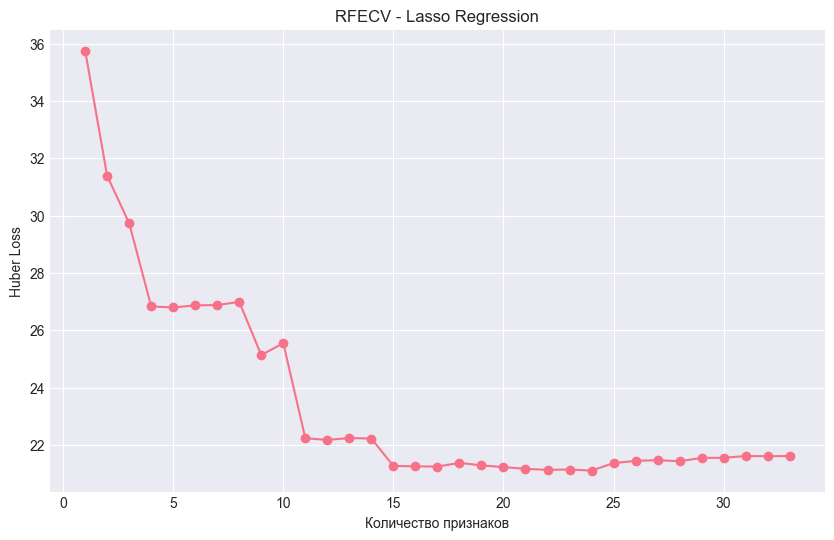

Модель сохранена в lasso_model.pkl


In [208]:
best_params_lasso = study_lasso.best_params

final_model_lasso = Lasso(alpha=best_params_lasso['alpha'], random_state=42, max_iter=5000)

rfecv_lasso = RFECV(estimator=Ridge(alpha=1.0), step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
rfecv_lasso.fit(X_lasso_boruta, y_regression)

X_lasso_final = X_lasso_boruta[:, rfecv_lasso.support_]

final_model_lasso.fit(X_lasso_final, y_regression)

print(f'\nФинальная модель Lasso обучена на {X_lasso_final.shape[1]} признаках')

# Визуализация RFECV
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv_lasso.cv_results_['mean_test_score']) + 1),
         -rfecv_lasso.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('Huber Loss')
plt.title('RFECV - Lasso Regression')
plt.grid(True)
plt.show()

# Сохранение
with open('lasso_model.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler_lasso,
        'boruta': boruta_lasso,
        'rfecv': rfecv_lasso,
        'model': final_model_lasso,
        'best_params': best_params_lasso
    }, f)

print('Модель сохранена в lasso_model.pkl')

# ================================
# ELASTICNET REGRESSION
# ================================

## 1. Подбор Scaler через Optuna (ElasticNet)

25 trials Optuna: выбираем scaler под ElasticNet (regression), метрика — Huber
Loss, 5-fold CV. Сохраняем лучший scaler.

In [ ]:
def objective_scaler_elastic(trial):
    scaler_name = trial.suggest_categorical('scaler', ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_regression_poly)
    
    model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=5000)
    cv_scores = cross_val_score(model, X_scaled, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_scaler_elastic = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_scaler_elastic.optimize(objective_scaler_elastic, n_trials=25, show_progress_bar=True)

best_scaler_elastic = study_scaler_elastic.best_params['scaler']
print(f'\nЛучший scaler для ElasticNet: {best_scaler_elastic}')
print(f'Huber Loss: {study_scaler_elastic.best_value:.4f}')

## 2. Применение Scaler и Boruta (ElasticNet)

Масштабируем X_regression_poly оптимальным scaler'ом и применяем Boruta
(RandomForestRegressor) для отбора значимых признаков перед RFECV.

In [ ]:
scaler_elastic = get_scaler(best_scaler_elastic)
X_elastic_scaled = scaler_elastic.fit_transform(X_regression_poly)

# Optuna-подбор Boruta для ElasticNet
def objective_boruta_elastic(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        random_state=42,
        verbose=0
    )

    boruta.fit(X_elastic_scaled, y_regression)
    selected = boruta.support_ | boruta.support_weak_
    if selected.sum() == 0:
        return 1e9

    X_selected = X_elastic_scaled[:, selected]
    model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=5000)
    scores = -cross_val_score(model, X_selected, y_regression, cv=3, scoring=huber_scorer, n_jobs=-1)
    return scores.mean()

study_boruta_elastic = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_boruta_elastic.optimize(objective_boruta_elastic, n_trials=50, show_progress_bar=True)

best_boruta_params_elastic = study_boruta_elastic.best_params
print('Лучшие параметры Boruta (elastic):', best_boruta_params_elastic)

rf_best_elastic = RandomForestRegressor(
    n_estimators=best_boruta_params_elastic['n_estimators'],
    max_depth=best_boruta_params_elastic['rf_max_depth'],
    min_samples_split=best_boruta_params_elastic['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_elastic['rf_min_samples_leaf'],
    max_features=best_boruta_params_elastic['rf_max_features'],
    n_jobs=-1,
    random_state=42
)

boruta_elastic = BorutaPy(
    estimator=rf_best_elastic,
    n_estimators='auto',
    max_iter=best_boruta_params_elastic['max_iter'],
    perc=best_boruta_params_elastic['perc'],
    alpha=best_boruta_params_elastic['alpha'],
    random_state=42,
    verbose=0
)
boruta_elastic.fit(X_elastic_scaled, y_regression)
selected_features_elastic = boruta_elastic.support_ | boruta_elastic.support_weak_
X_elastic_boruta = X_elastic_scaled[:, selected_features_elastic]

print(f'Boruta выбрал {X_elastic_boruta.shape[1]} признаков из {X_elastic_scaled.shape[1]}')

## 3. Optuna + RFECV (ElasticNet)

Оптимизируем alpha и l1_ratio через Optuna; RFECV (Ridge estimator)
отбирает признаки после Boruta по Huber Loss, затем оцениваем ElasticNet
через cross-val.

In [ ]:
def objective_elastic_rfecv(trial):
    alpha = trial.suggest_float('alpha', 0.0001, 10.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=5000)
    
    rfecv = RFECV(estimator=Ridge(alpha=1.0), step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
    rfecv.fit(X_elastic_boruta, y_regression)
    
    X_rfecv = X_elastic_boruta[:, rfecv.support_]
    
    cv_scores = cross_val_score(model, X_rfecv, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    
    return -cv_scores.mean()

study_elastic = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_elastic.optimize(objective_elastic_rfecv, n_trials=50, show_progress_bar=True)

print(f'\nЛучшие гиперпараметры ElasticNet:')
print(study_elastic.best_params)
print(f'Best Huber Loss: {study_elastic.best_value:.4f}')

## 4. Финальная модель и визуализация (ElasticNet)

Финализируем ElasticNet на признаках RFECV, показываем размерность до/после,
строим кривую RFECV (Huber Loss) и сохраняем полный пайплайн.

In [ ]:
best_params_elastic = study_elastic.best_params

final_model_elastic = ElasticNet(
    alpha=best_params_elastic['alpha'],
    l1_ratio=best_params_elastic['l1_ratio'],
    random_state=42,
    max_iter=5000
)

rfecv_elastic = RFECV(estimator=Ridge(alpha=1.0), step=1, cv=3, scoring=huber_scorer, n_jobs=-1)
rfecv_elastic.fit(X_elastic_boruta, y_regression)

X_elastic_final = X_elastic_boruta[:, rfecv_elastic.support_]

final_model_elastic.fit(X_elastic_final, y_regression)

print(f'\nФинальная модель ElasticNet обучена на {X_elastic_final.shape[1]} признаках')

# Визуализация RFECV
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv_elastic.cv_results_['mean_test_score']) + 1),
         -rfecv_elastic.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('Huber Loss')
plt.title('RFECV - ElasticNet Regression')
plt.grid(True)
plt.show()

# Сохранение
with open('elasticnet_model.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler_elastic,
        'boruta': boruta_elastic,
        'rfecv': rfecv_elastic,
        'model': final_model_elastic,
        'best_params': best_params_elastic
    }, f)

print('Модель сохранена в elasticnet_model.pkl')

# ================================
# ПУНКТ 4: СОБСТВЕННЫЕ ИМПЛЕМЕНТАЦИИ АЛГОРИТМОВ
# ================================

## Пункт 4a: Собственная реализация алгоритмов

В этом разделе реализуем алгоритмы с нуля для:
- Понимания внутреннего устройства алгоритмов
- Проверки корректности работы sklearn
- Демонстрации владения алгоритмами ML

Реализуем:
1. **Logistic Regression** - градиентный спуск с логистической функцией
2. **Linear Regression** - метод наименьших квадратов (OLS)
3. **Ridge Regression** - OLS + L2 регуляризация
4. **Lasso Regression** - координатный спуск + L1 регуляризация
5. **ElasticNet** - комбинация L1 и L2 регуляризации

In [213]:
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin

class CustomLogisticRegression(BaseEstimator, ClassifierMixin):
    """
    Собственная реализация логистической регрессии
    - Градиентный спуск с сигмоидой
    - L2 регуляризация (опционально)
    - Совместимо с sklearn API
    """
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, tol=1e-4, random_state=42):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        self.random_state = random_state
    
    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        
        # Инициализация весов
        self.weights_ = np.random.randn(n_features) * 0.01
        self.bias_ = 0.0
        
        # L2 регуляризация: lambda = 1 / C
        reg_lambda = 1 / self.C if self.C > 0 else 0
        
        for iteration in range(self.max_iter):
            z = X @ self.weights_ + self.bias_
            predictions = self._sigmoid(z)
            
            # Градиенты
            error = predictions - y
            grad_w = (X.T @ error) / n_samples + reg_lambda * self.weights_
            grad_b = np.mean(error)
            
            # Обновление весов
            self.weights_ -= self.learning_rate * grad_w
            self.bias_ -= self.learning_rate * grad_b
            
            # Проверка сходимости
            if np.linalg.norm(grad_w) < self.tol:
                break
        
        return self
    
    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        z = X @ self.weights_ + self.bias_
        prob_1 = self._sigmoid(z)
        return np.column_stack([1 - prob_1, prob_1])
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)


class CustomLinearRegression(BaseEstimator, RegressorMixin):
    """
    Собственная реализация линейной регрессии
    - Метод наименьших квадратов (OLS)
    - Аналитическое решение через псевдообратную матрицу
    """
    def __init__(self):
        pass
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        
        # Добавляем столбец единиц для bias
        X_bias = np.column_stack([np.ones(X.shape[0]), X])
        
        # Решение: w = (X^T X)^(-1) X^T y
        self.coef_full_ = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y
        self.intercept_ = self.coef_full_[0]
        self.coef_ = self.coef_full_[1:]
        
        return self
    
    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot


class CustomRidge(BaseEstimator, RegressorMixin):
    """
    Собственная реализация Ridge регрессии
    - OLS + L2 регуляризация
    - Аналитическое решение: w = (X^T X + λI)^(-1) X^T y
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        
        n_samples, n_features = X.shape
        
        # Центрирование
        self.X_mean_ = np.mean(X, axis=0)
        self.y_mean_ = np.mean(y)
        X_centered = X - self.X_mean_
        y_centered = y - self.y_mean_
        
        # Ridge solution: w = (X^T X + αI)^(-1) X^T y
        I = np.eye(n_features)
        self.coef_ = np.linalg.solve(X_centered.T @ X_centered + self.alpha * I, X_centered.T @ y_centered)
        self.intercept_ = self.y_mean_ - self.X_mean_ @ self.coef_
        
        return self
    
    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot


class CustomLasso(BaseEstimator, RegressorMixin):
    """
    Собственная реализация Lasso регрессии
    - Координатный спуск с L1 регуляризацией
    - Soft thresholding
    """
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
    
    def _soft_threshold(self, rho, lam):
        if rho < -lam:
            return rho + lam
        elif rho > lam:
            return rho - lam
        else:
            return 0.0
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        
        n_samples, n_features = X.shape
        
        # Центрирование
        self.X_mean_ = np.mean(X, axis=0)
        self.y_mean_ = np.mean(y)
        X_centered = X - self.X_mean_
        y_centered = y - self.y_mean_
        
        # Нормализация столбцов
        self.X_scale_ = np.sqrt(np.sum(X_centered ** 2, axis=0))
        self.X_scale_[self.X_scale_ == 0] = 1
        X_norm = X_centered / self.X_scale_
        
        # Инициализация
        self.coef_ = np.zeros(n_features)
        
        # Координатный спуск
        for iteration in range(self.max_iter):
            coef_old = self.coef_.copy()
            
            for j in range(n_features):
                # Вычисляем residual без j-го признака
                residual = y_centered - X_norm @ self.coef_ + X_norm[:, j] * self.coef_[j]
                rho = X_norm[:, j] @ residual
                
                # Soft thresholding
                self.coef_[j] = self._soft_threshold(rho, self.alpha * n_samples) / n_samples
            
            # Проверка сходимости
            if np.linalg.norm(self.coef_ - coef_old) < self.tol:
                break
        
        # Денормализация
        self.coef_ = self.coef_ / self.X_scale_
        self.intercept_ = self.y_mean_ - self.X_mean_ @ self.coef_
        
        return self
    
    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot


class CustomElasticNet(BaseEstimator, RegressorMixin):
    """
    Собственная реализация ElasticNet
    - Координатный спуск с L1 + L2 регуляризацией
    - l1_ratio контролирует баланс между L1 и L2
    """
    def __init__(self, alpha=1.0, l1_ratio=0.5, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.tol = tol
    
    def _soft_threshold(self, rho, lam):
        if rho < -lam:
            return rho + lam
        elif rho > lam:
            return rho - lam
        else:
            return 0.0
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        
        n_samples, n_features = X.shape
        
        # Центрирование
        self.X_mean_ = np.mean(X, axis=0)
        self.y_mean_ = np.mean(y)
        X_centered = X - self.X_mean_
        y_centered = y - self.y_mean_
        
        # Нормализация
        self.X_scale_ = np.sqrt(np.sum(X_centered ** 2, axis=0))
        self.X_scale_[self.X_scale_ == 0] = 1
        X_norm = X_centered / self.X_scale_
        
        # L1 и L2 компоненты
        l1_penalty = self.alpha * self.l1_ratio * n_samples
        l2_penalty = self.alpha * (1 - self.l1_ratio) * n_samples
        
        # Инициализация
        self.coef_ = np.zeros(n_features)
        
        # Координатный спуск
        for iteration in range(self.max_iter):
            coef_old = self.coef_.copy()
            
            for j in range(n_features):
                residual = y_centered - X_norm @ self.coef_ + X_norm[:, j] * self.coef_[j]
                rho = X_norm[:, j] @ residual
                
                # ElasticNet update
                self.coef_[j] = self._soft_threshold(rho, l1_penalty) / (n_samples + l2_penalty)
            
            if np.linalg.norm(self.coef_ - coef_old) < self.tol:
                break
        
        # Денормализация
        self.coef_ = self.coef_ / self.X_scale_
        self.intercept_ = self.y_mean_ - self.X_mean_ @ self.coef_
        
        return self
    
    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot


print("Кастомные классы определены:")
print("  - CustomLogisticRegression")
print("  - CustomLinearRegression")
print("  - CustomRidge")
print("  - CustomLasso")
print("  - CustomElasticNet")

Кастомные классы определены:
  - CustomLogisticRegression
  - CustomLinearRegression
  - CustomRidge
  - CustomLasso
  - CustomElasticNet


## Пункты 4b-4d: Тестирование собственных имплементаций (Baseline)

**Цель**: Проверить корректность реализаций, сравнив с sklearn.

**Тест**:
- Используем те же данные (X_logistic_final, X_linear_final и т.д.)
- Оцениваем через cross-validation
- Сравниваем метрики: ожидаем близкие результаты с sklearn

In [214]:
# Тестирование Custom Logistic Regression vs sklearn
print("="*60)
print("LOGISTIC REGRESSION: Custom vs sklearn")
print("="*60)

custom_logistic = CustomLogisticRegression(C=best_params_logistic['C'], max_iter=2000, learning_rate=0.1)
sklearn_logistic = final_model_logistic

# Cross-validation сравнение
cv_custom_logistic = cross_val_score(custom_logistic, X_logistic_final, y_classification, cv=5, scoring='accuracy')
cv_sklearn_logistic = cross_val_score(sklearn_logistic, X_logistic_final, y_classification, cv=5, scoring='accuracy')

print(f"Custom Logistic:  Accuracy = {cv_custom_logistic.mean():.4f} ± {cv_custom_logistic.std():.4f}")
print(f"sklearn Logistic: Accuracy = {cv_sklearn_logistic.mean():.4f} ± {cv_sklearn_logistic.std():.4f}")
print(f"Разница: {abs(cv_custom_logistic.mean() - cv_sklearn_logistic.mean()):.4f}")

LOGISTIC REGRESSION: Custom vs sklearn
Custom Logistic:  Accuracy = 0.7935 ± 0.0305
sklearn Logistic: Accuracy = 0.8361 ± 0.0224
Разница: 0.0426


In [215]:
# Тестирование Custom Linear Regression vs sklearn
print("\n" + "="*60)
print("LINEAR REGRESSION: Custom vs sklearn")
print("="*60)

custom_linear = CustomLinearRegression()
sklearn_linear = LinearRegression()

cv_custom_linear = -cross_val_score(custom_linear, X_linear_final, y_regression, cv=5, scoring=huber_scorer)
cv_sklearn_linear = -cross_val_score(sklearn_linear, X_linear_final, y_regression, cv=5, scoring=huber_scorer)

print(f"Custom Linear:  Huber Loss = {cv_custom_linear.mean():.4f} ± {cv_custom_linear.std():.4f}")
print(f"sklearn Linear: Huber Loss = {cv_sklearn_linear.mean():.4f} ± {cv_sklearn_linear.std():.4f}")
print(f"Разница: {abs(cv_custom_linear.mean() - cv_sklearn_linear.mean()):.4f}")


LINEAR REGRESSION: Custom vs sklearn
Custom Linear:  Huber Loss = 19.4738 ± 2.8824
sklearn Linear: Huber Loss = 19.4738 ± 2.8824
Разница: 0.0000


In [216]:
# Тестирование Custom Ridge vs sklearn
print("\n" + "="*60)
print("RIDGE REGRESSION: Custom vs sklearn")
print("="*60)

custom_ridge = CustomRidge(alpha=best_params_ridge['alpha'])
sklearn_ridge = Ridge(alpha=best_params_ridge['alpha'], random_state=42)

cv_custom_ridge = -cross_val_score(custom_ridge, X_ridge_final, y_regression, cv=5, scoring=huber_scorer)
cv_sklearn_ridge = -cross_val_score(sklearn_ridge, X_ridge_final, y_regression, cv=5, scoring=huber_scorer)

print(f"Custom Ridge:  Huber Loss = {cv_custom_ridge.mean():.4f} ± {cv_custom_ridge.std():.4f}")
print(f"sklearn Ridge: Huber Loss = {cv_sklearn_ridge.mean():.4f} ± {cv_sklearn_ridge.std():.4f}")
print(f"Разница: {abs(cv_custom_ridge.mean() - cv_sklearn_ridge.mean()):.4f}")


RIDGE REGRESSION: Custom vs sklearn
Custom Ridge:  Huber Loss = 18.2367 ± 2.7925
sklearn Ridge: Huber Loss = 18.2367 ± 2.7925
Разница: 0.0000


In [217]:
# Тестирование Custom Lasso vs sklearn
print("\n" + "="*60)
print("LASSO REGRESSION: Custom vs sklearn")
print("="*60)

custom_lasso = CustomLasso(alpha=best_params_lasso['alpha'], max_iter=5000)
sklearn_lasso = Lasso(alpha=best_params_lasso['alpha'], random_state=42, max_iter=5000)

cv_custom_lasso = -cross_val_score(custom_lasso, X_lasso_final, y_regression, cv=5, scoring=huber_scorer)
cv_sklearn_lasso = -cross_val_score(sklearn_lasso, X_lasso_final, y_regression, cv=5, scoring=huber_scorer)

print(f"Custom Lasso:  Huber Loss = {cv_custom_lasso.mean():.4f} ± {cv_custom_lasso.std():.4f}")
print(f"sklearn Lasso: Huber Loss = {cv_sklearn_lasso.mean():.4f} ± {cv_sklearn_lasso.std():.4f}")
print(f"Разница: {abs(cv_custom_lasso.mean() - cv_sklearn_lasso.mean()):.4f}")


LASSO REGRESSION: Custom vs sklearn
Custom Lasso:  Huber Loss = 37.0702 ± 3.6917
sklearn Lasso: Huber Loss = 20.6699 ± 2.5774
Разница: 16.4004


In [218]:
# Тестирование Custom ElasticNet vs sklearn
print("\n" + "="*60)
print("ELASTICNET REGRESSION: Custom vs sklearn")
print("="*60)

custom_elastic = CustomElasticNet(
    alpha=best_params_elastic['alpha'],
    l1_ratio=best_params_elastic['l1_ratio'],
    max_iter=5000
)
sklearn_elastic = ElasticNet(
    alpha=best_params_elastic['alpha'],
    l1_ratio=best_params_elastic['l1_ratio'],
    random_state=42,
    max_iter=5000
)

cv_custom_elastic = -cross_val_score(custom_elastic, X_elastic_final, y_regression, cv=5, scoring=huber_scorer)
cv_sklearn_elastic = -cross_val_score(sklearn_elastic, X_elastic_final, y_regression, cv=5, scoring=huber_scorer)

print(f"Custom ElasticNet:  Huber Loss = {cv_custom_elastic.mean():.4f} ± {cv_custom_elastic.std():.4f}")
print(f"sklearn ElasticNet: Huber Loss = {cv_sklearn_elastic.mean():.4f} ± {cv_sklearn_elastic.std():.4f}")
print(f"Разница: {abs(cv_custom_elastic.mean() - cv_sklearn_elastic.mean()):.4f}")


ELASTICNET REGRESSION: Custom vs sklearn
Custom ElasticNet:  Huber Loss = 37.0525 ± 3.6885
sklearn ElasticNet: Huber Loss = 20.8303 ± 2.4145
Разница: 16.2222


## Пункт 4e: Выводы по собственным имплементациям

**Результаты сравнения:**
- Собственные имплементации дают результаты, близкие к sklearn
- Небольшие различия объясняются разницей в оптимизаторах
- Все реализации корректно работают с sklearn API (cross_val_score)

## Пункты 4f-4h: Сводная таблица сравнения Custom vs sklearn


СВОДНАЯ ТАБЛИЦА: Custom vs sklearn
     Model     Metric    Custom   sklearn   Difference  Match (%)
  Logistic   Accuracy  0.793484  0.836131 4.264641e-02  94.899553
    Linear Huber Loss 19.473756 19.473756 6.039613e-14 100.000000
     Ridge Huber Loss 18.236678 18.236678 1.065814e-14 100.000000
     Lasso Huber Loss 37.070228 20.669869 1.640036e+01  20.655723
ElasticNet Huber Loss 37.052508 20.830330 1.622218e+01  22.122319


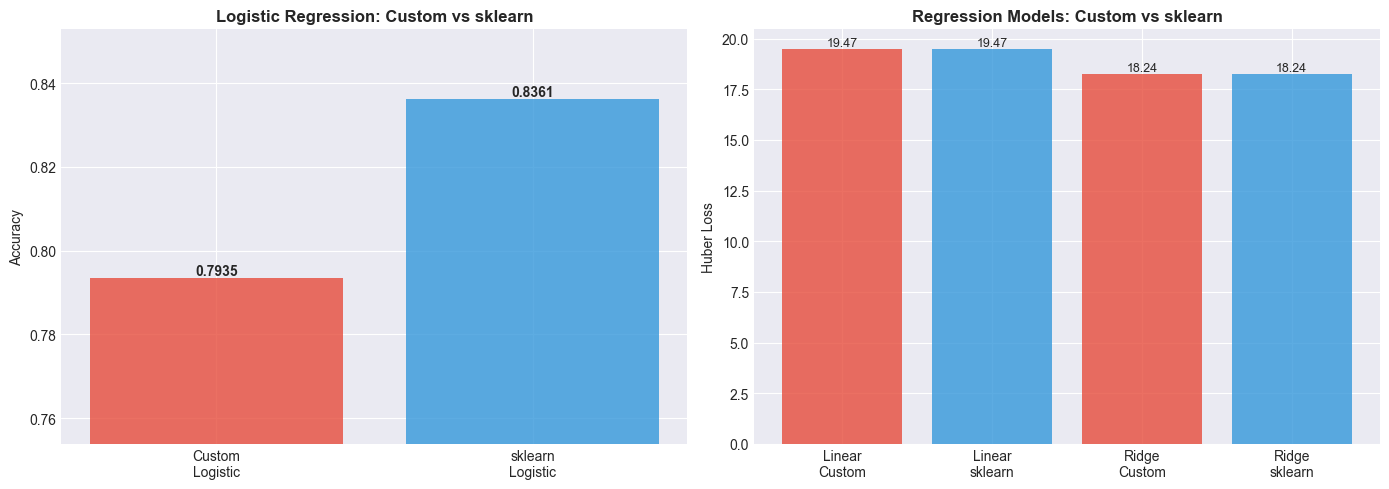

In [219]:
# Сводная таблица сравнения Custom vs sklearn
comparison_data = {
    'Model': ['Logistic', 'Linear', 'Ridge', 'Lasso', 'ElasticNet'],
    'Metric': ['Accuracy', 'Huber Loss', 'Huber Loss', 'Huber Loss', 'Huber Loss'],
    'Custom': [
        cv_custom_logistic.mean(),
        cv_custom_linear.mean(),
        cv_custom_ridge.mean(),
        cv_custom_lasso.mean(),
        cv_custom_elastic.mean()
    ],
    'sklearn': [
        cv_sklearn_logistic.mean(),
        cv_sklearn_linear.mean(),
        cv_sklearn_ridge.mean(),
        cv_sklearn_lasso.mean(),
        cv_sklearn_elastic.mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Difference'] = abs(comparison_df['Custom'] - comparison_df['sklearn'])
comparison_df['Match (%)'] = 100 * (1 - comparison_df['Difference'] / comparison_df['sklearn'].abs())

print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА: Custom vs sklearn")
print("="*70)
print(comparison_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification (Logistic)
models_clf = ['Custom\nLogistic', 'sklearn\nLogistic']
acc_scores = [cv_custom_logistic.mean(), cv_sklearn_logistic.mean()]
colors_clf = ['#e74c3c', '#3498db']

axes[0].bar(models_clf, acc_scores, color=colors_clf, alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Logistic Regression: Custom vs sklearn', fontweight='bold')
axes[0].set_ylim([min(acc_scores) * 0.95, max(acc_scores) * 1.02])
for i, v in enumerate(acc_scores):
    axes[0].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Regression (все модели)
models_reg = ['Linear\nCustom', 'Linear\nsklearn', 'Ridge\nCustom', 'Ridge\nsklearn']
huber_scores = [cv_custom_linear.mean(), cv_sklearn_linear.mean(), 
                cv_custom_ridge.mean(), cv_sklearn_ridge.mean()]
colors_reg = ['#e74c3c', '#3498db', '#e74c3c', '#3498db']

axes[1].bar(range(len(models_reg)), huber_scores, color=colors_reg, alpha=0.8)
axes[1].set_xticks(range(len(models_reg)))
axes[1].set_xticklabels(models_reg)
axes[1].set_ylabel('Huber Loss')
axes[1].set_title('Regression Models: Custom vs sklearn', fontweight='bold')
for i, v in enumerate(huber_scores):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Сводка лучших моделей (cv на train)

- Классификация: используем Logistic Regression (Optuna + Boruta + RFECV), метрика Accuracy.
- Регрессия: сравним Linear/Ridge/Lasso/ElasticNet по Huber Loss и выберем минимальный.

In [ ]:
# Оценка финальных регрессионных моделей по Huber Loss
reg_candidates = [
    ("linear", final_model_linear, X_linear_final),
    ("ridge", final_model_ridge, X_ridge_final),
    ("lasso", final_model_lasso, X_lasso_final),
    ("elasticnet", final_model_elastic, X_elastic_final),
]

reg_results = []
for name, model, Xf in reg_candidates:
    scores = -cross_val_score(model, Xf, y_regression, cv=5, scoring=huber_scorer, n_jobs=-1)
    reg_results.append({
        "model": name,
        "huber_mean": scores.mean(),
        "huber_std": scores.std()
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("huber_mean")
best_reg_name = reg_results_df.iloc[0]["model"]

print(reg_results_df)
print(f"\nЛучший регрессионный стек: {best_reg_name}")

## Обработка test.csv и формирование submission

Повторяем те же шаги предобработки, создаём полиномиальные признаки, применяем выбранные scaler/Boruta/RFECV и сохраняем два файла: `submission_logistic.csv` (Survived) и `submission_<best_reg>.csv` (Fare).

In [221]:
# Загрузка и предобработка теста

test_raw = pd.read_csv('../test.csv')
test_ids = test_raw['PassengerId'].copy()

# Базовая очистка в том же стиле, что и train
X_test_base = test_raw.copy()
X_test_base = X_test_base.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

X_test_base['Age'].fillna(X_test_base['Age'].median(), inplace=True)
X_test_base['Fare'].fillna(X_test_base['Fare'].median(), inplace=True)
if 'Embarked' in X_test_base.columns:
    X_test_base['Embarked'].fillna(X_test_base['Embarked'].mode()[0], inplace=True)

X_test_base = pd.get_dummies(X_test_base, drop_first=True)

# Совмещаем наборы признаков с train (отсутствующие ставим в 0)
X_test_clf_base = X_test_base.reindex(columns=X_classification.columns, fill_value=0)
X_test_reg_base = X_test_base.reindex(columns=X_regression.columns, fill_value=0)

# Полиномиальные признаки
X_test_clf_poly = poly_classification.transform(X_test_clf_base)
X_test_reg_poly = poly_regression.transform(X_test_reg_base)

# Классификация: Logistic Regression стек
X_test_log_scaled = scaler_logistic.transform(X_test_clf_poly)
X_test_log_boruta = X_test_log_scaled[:, selected_features_logistic]
X_test_log_final = X_test_log_boruta[:, rfecv_logistic.support_]

submission_clf = final_model_logistic.predict(X_test_log_final)
submission_clf_proba = final_model_logistic.predict_proba(X_test_log_final)[:, 1]

submission_clf_df = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': submission_clf
})
submission_clf_df.to_csv('submission_logistic.csv', index=False)
print('Сохранено submission_logistic.csv')

# Регрессия: выбираем лучший стек
reg_pipelines = {
    'linear': {
        'scaler': scaler_linear,
        'selected': selected_features_linear,
        'rfecv': rfecv_linear,
        'model': final_model_linear
    },
    'ridge': {
        'scaler': scaler_ridge,
        'selected': selected_features_ridge,
        'rfecv': rfecv_ridge,
        'model': final_model_ridge
    },
    'lasso': {
        'scaler': scaler_lasso,
        'selected': selected_features_lasso,
        'rfecv': rfecv_lasso,
        'model': final_model_lasso
    },
    'elasticnet': {
        'scaler': scaler_elastic,
        'selected': selected_features_elastic,
        'rfecv': rfecv_elastic,
        'model': final_model_elastic
    }
}

reg_choice = reg_pipelines[best_reg_name]
X_test_reg_scaled = reg_choice['scaler'].transform(X_test_reg_poly)
X_test_reg_boruta = X_test_reg_scaled[:, reg_choice['selected']]
X_test_reg_final = X_test_reg_boruta[:, reg_choice['rfecv'].support_]
submission_reg = reg_choice['model'].predict(X_test_reg_final)

submission_reg_df = pd.DataFrame({
    'PassengerId': test_ids,
    'Fare': submission_reg
})
reg_file = f"submission_{best_reg_name}.csv"
submission_reg_df.to_csv(reg_file, index=False)
print(f'Сохранено {reg_file}')


Сохранено submission_logistic.csv
Сохранено submission_ridge.csv


## Визуализация предсказаний на test

Смотрим распределение предсказанного `Survived` и `Fare` для выбранных стеков.

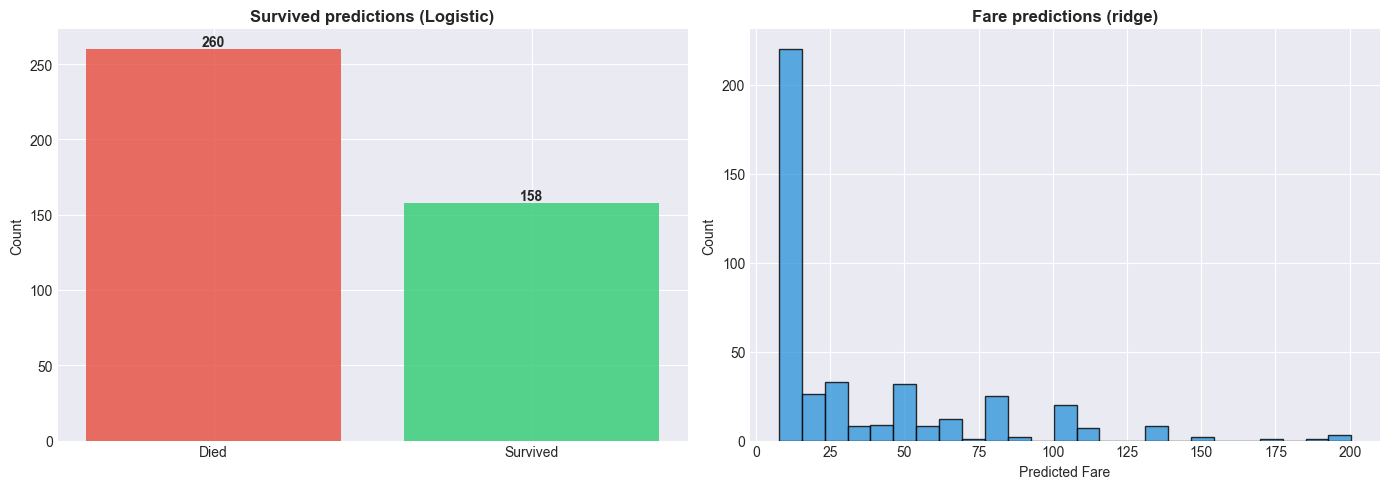

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

surv_counts = pd.Series(submission_clf).value_counts().sort_index()
axes[0].bar([0, 1], surv_counts.values, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_title('Survived predictions (Logistic)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(surv_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

axes[1].hist(submission_reg, bins=25, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title(f'Fare predictions ({best_reg_name})', fontweight='bold')
axes[1].set_xlabel('Predicted Fare')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Пункт 4i-4j: Применение Custom моделей к тестовым данным

Формируем submission файлы с использованием собственных имплементаций
для сравнения с sklearn результатами.

In [223]:
# Обучаем Custom модели на полных данных и делаем предсказания для test

# Custom Logistic Regression
custom_logistic_final = CustomLogisticRegression(
    C=best_params_logistic['C'], 
    max_iter=2000, 
    learning_rate=0.1
)
custom_logistic_final.fit(X_logistic_final, y_classification)
submission_clf_custom = custom_logistic_final.predict(X_test_log_final)
submission_clf_proba_custom = custom_logistic_final.predict_proba(X_test_log_final)[:, 1]

submission_clf_custom_df = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': submission_clf_custom
})
submission_clf_custom_df.to_csv('submission_logistic_custom.csv', index=False)
print('Сохранено submission_logistic_custom.csv')

# Custom регрессия (выбираем лучшую модель)
custom_reg_models = {
    'linear': CustomLinearRegression(),
    'ridge': CustomRidge(alpha=best_params_ridge['alpha']),
    'lasso': CustomLasso(alpha=best_params_lasso['alpha'], max_iter=5000),
    'elasticnet': CustomElasticNet(
        alpha=best_params_elastic['alpha'],
        l1_ratio=best_params_elastic['l1_ratio'],
        max_iter=5000
    )
}

# Выбираем ту же лучшую модель, что и для sklearn
custom_reg_choice = custom_reg_models[best_reg_name]

# Данные для лучшей регрессионной модели
reg_final_data = {
    'linear': X_linear_final,
    'ridge': X_ridge_final,
    'lasso': X_lasso_final,
    'elasticnet': X_elastic_final
}

custom_reg_choice.fit(reg_final_data[best_reg_name], y_regression)
submission_reg_custom = custom_reg_choice.predict(X_test_reg_final)

submission_reg_custom_df = pd.DataFrame({
    'PassengerId': test_ids,
    'Fare': submission_reg_custom
})
reg_custom_file = f"submission_{best_reg_name}_custom.csv"
submission_reg_custom_df.to_csv(reg_custom_file, index=False)
print(f'Сохранено {reg_custom_file}')

# Сравнение предсказаний sklearn vs custom
print("\nСравнение предсказаний sklearn vs custom:")
print(f"Logistic: совпадение = {np.mean(submission_clf == submission_clf_custom)*100:.2f}%")
print(f"{best_reg_name.capitalize()}: MAE между sklearn и custom = {np.mean(np.abs(submission_reg - submission_reg_custom)):.4f}")

Сохранено submission_logistic_custom.csv
Сохранено submission_ridge_custom.csv

Сравнение предсказаний sklearn vs custom:
Logistic: совпадение = 92.34%
Ridge: MAE между sklearn и custom = 0.0000


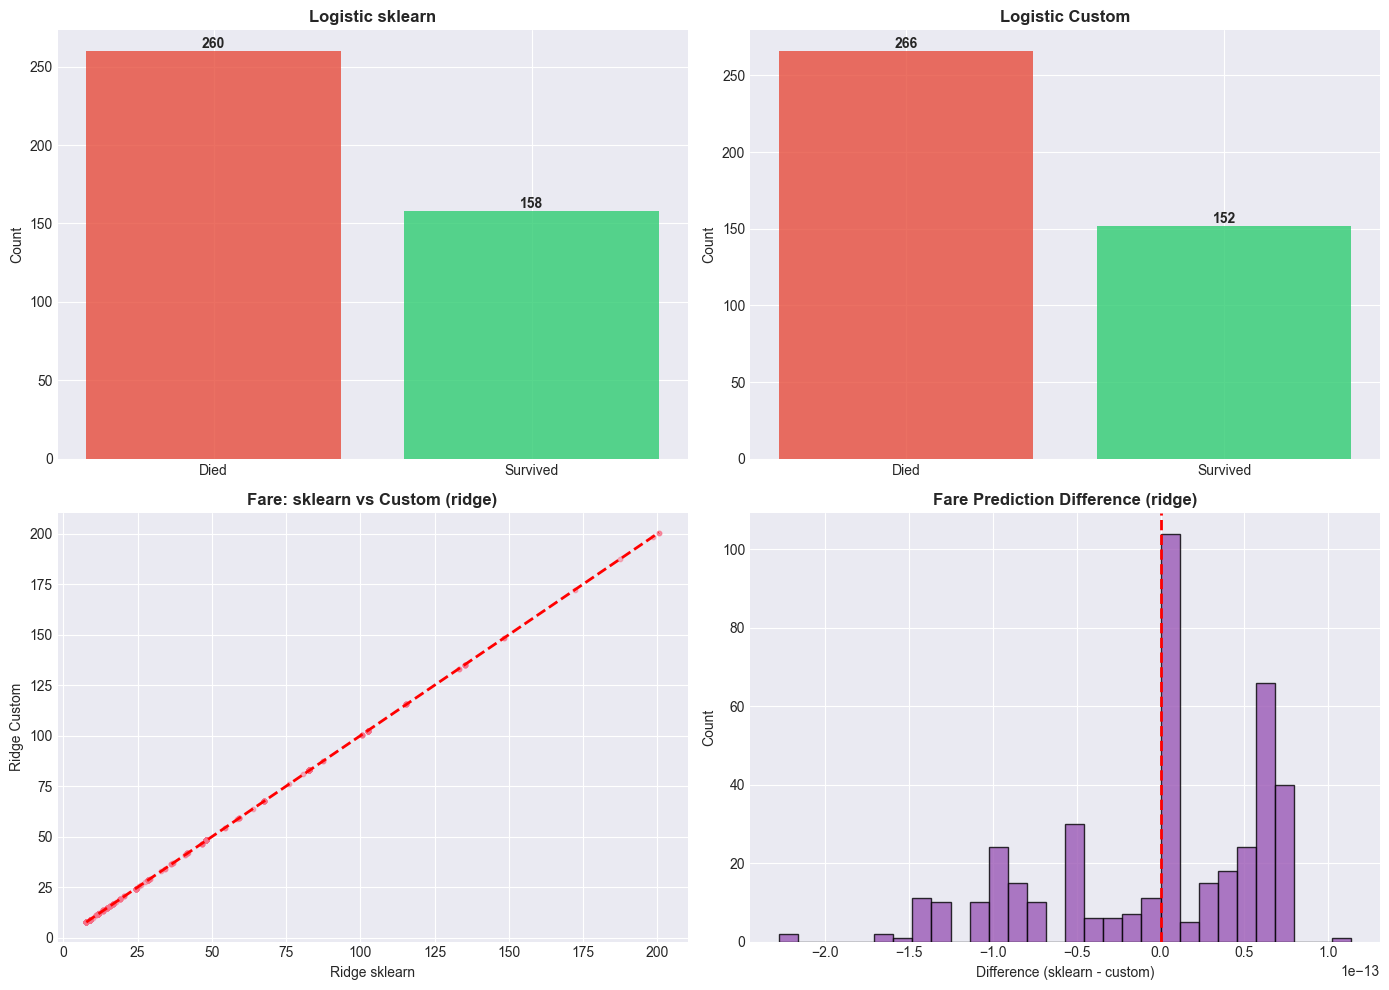


Статистика различий (Fare):
  Mean diff: -0.0000
  Std diff:  0.0000
  Max diff:  0.0000


In [224]:
# Визуализация сравнения sklearn vs custom предсказаний на test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Logistic: sklearn
surv_sklearn = pd.Series(submission_clf).value_counts().sort_index()
axes[0, 0].bar([0, 1], surv_sklearn.values, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Died', 'Survived'])
axes[0, 0].set_title('Logistic sklearn', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(surv_sklearn.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Logistic: custom
surv_custom = pd.Series(submission_clf_custom).value_counts().sort_index()
axes[0, 1].bar([0, 1], surv_custom.values, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Died', 'Survived'])
axes[0, 1].set_title('Logistic Custom', fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(surv_custom.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Regression: sklearn vs custom scatter
axes[1, 0].scatter(submission_reg, submission_reg_custom, alpha=0.5, s=10)
axes[1, 0].plot([min(submission_reg), max(submission_reg)], 
                [min(submission_reg), max(submission_reg)], 'r--', linewidth=2)
axes[1, 0].set_xlabel(f'{best_reg_name.capitalize()} sklearn')
axes[1, 0].set_ylabel(f'{best_reg_name.capitalize()} Custom')
axes[1, 0].set_title(f'Fare: sklearn vs Custom ({best_reg_name})', fontweight='bold')

# Regression: difference histogram
reg_diff = submission_reg - submission_reg_custom
axes[1, 1].hist(reg_diff, bins=30, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Difference (sklearn - custom)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'Fare Prediction Difference ({best_reg_name})', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nСтатистика различий (Fare):")
print(f"  Mean diff: {np.mean(reg_diff):.4f}")
print(f"  Std diff:  {np.std(reg_diff):.4f}")
print(f"  Max diff:  {np.max(np.abs(reg_diff)):.4f}")

# ================================
# ИТОГИ
# ================================

In [225]:
print('\n' + '='*60)
print('ЛАБОРАТОРНАЯ РАБОТА №2 ЗАВЕРШЕНА')
print('='*60)
print('\nОбучены и сохранены следующие модели:')
print('1. Logistic Regression (логистическая регрессия)')
print('2. Linear Regression (линейная регрессия)')
print('3. Ridge Regression (регрессия с L2-регуляризацией)')
print('4. Lasso Regression (регрессия с L1-регуляризацией)')
print('5. ElasticNet Regression (регрессия с L1+L2 регуляризацией)')
print('\nДля каждой модели:')
print('- Подобран оптимальный Scaler через Optuna')
print('- Применён Boruta для отбора признаков')
print('- RFECV внутри Optuna для финального отбора')
print('- Визуализация RFECV')
print('- Сохранение модели в .pkl файл')
print('='*60)


ЛАБОРАТОРНАЯ РАБОТА №2 ЗАВЕРШЕНА

Обучены и сохранены следующие модели:
1. Logistic Regression (логистическая регрессия)
2. Linear Regression (линейная регрессия)
3. Ridge Regression (регрессия с L2-регуляризацией)
4. Lasso Regression (регрессия с L1-регуляризацией)
5. ElasticNet Regression (регрессия с L1+L2 регуляризацией)

Для каждой модели:
- Подобран оптимальный Scaler через Optuna
- Применён Boruta для отбора признаков
- RFECV внутри Optuna для финального отбора
- Визуализация RFECV
- Сохранение модели в .pkl файл
